
# Unlabeled Fraud Transactions: EDA, Hypotheses, and AI Angle (Unsupervised)

**Dataset:** Kaggle — *Financial Transactions Dataset: Analytics* → `transactions_data.csv`  
**Provided columns:** `id, date, client_id, card_id, amount, use_chip, merchant_id, merchant_city, merchant_state, zip, mcc, errors`

> Place `transactions_data.csv` next to this notebook or set `DATA_PATH` below.



## Problem Statement

We want to surface **suspicious transactions** to support fraud investigation.  
This file does **not** contain an explicit fraud label, so we will:
1. Perform **EDA** to understand behavioral patterns.
2. Form and test **hypotheses** that can guide rules/features.
3. Demonstrate an **unsupervised anomaly score** as a stand‑in risk signal.



## How We Will Use AI (Without Labels)

Because we lack ground‑truth fraud labels, we use **unsupervised** learning as a proxy:
- Engineer basic signals (amount, time of day, per‑card z‑scores, merchant frequency).
- Fit an **IsolationForest** to assign an **anomaly score** to each transaction.
- Use this score to triage transactions and to check whether certain groups (e.g., transactions with an entry in `errors`) look more anomalous.


In [1]:

# Imports and configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy import stats
except Exception as e:
    stats = None
    print("SciPy not available; statistical tests will be limited.")

try:
    from sklearn.ensemble import IsolationForest
    from sklearn.preprocessing import StandardScaler
    SKLEARN_AVAILABLE = True
except Exception as e:
    SKLEARN_AVAILABLE = False
    print("scikit-learn not available; skipping anomaly model.")

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True

DATA_PATH = Path('transactions_data.csv')


## Load and Clean

In [2]:

# Helper: parse dollar amounts like "$14.57" or "$-77.00" or "($12.34)"
def parse_amount(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = s.replace('$', '').replace(',', '')
    # Handle parentheses for negative
    neg = s.startswith('(') and s.endswith(')')
    s = s.strip('()')
    try:
        v = float(s)
        if neg:
            v = -v
        return v
    except:
        return np.nan

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing file: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(3))

# Enforce expected columns
expected = {'id','date','client_id','card_id','amount','use_chip','merchant_id',
            'merchant_city','merchant_state','zip','mcc','errors'}
missing_cols = expected - set(df.columns)
if missing_cols:
    print("WARNING: Missing expected columns:", missing_cols)

# Clean types
df['amount_num'] = df['amount'].apply(parse_amount)
df['is_refund'] = (df['amount_num'] < 0).astype(int)

# Parse timestamp
try:
    df['ts'] = pd.to_datetime(df['date'], errors='coerce', infer_datetime_format=True)
except Exception as e:
    print("Could not parse `date`:", e)
    df['ts'] = pd.NaT

# Basic time-derived features
if df['ts'].notna().any():
    df['hour'] = df['ts'].dt.hour
    df['dow']  = df['ts'].dt.dayofweek
else:
    df['hour'] = 0
    df['dow']  = 0

# Sanitize categorical-like fields
for c in ['use_chip','merchant_city','merchant_state','zip']:
    if c in df.columns:
        df[c] = df[c].astype(str)

# Numeric coercions
for c in ['client_id','card_id','merchant_id','mcc']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')


Shape: (13305915, 12)


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN


C:\Users\Oluwafemi Lawal\AppData\Local\Temp\ipykernel_15944\3410138274.py:38: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['ts'] = pd.to_datetime(df['date'], errors='coerce', infer_datetime_format=True)


## Exploratory Data Analysis (EDA)

Rows: 13305915
Time coverage: 2010-01-01 00:01:00 → 2019-10-31 23:59:00


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
amount,13305915,81161,$80.00,132115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount_num,13305915.0,NaN,NaN,NaN,42.976039,81.655748,-500.0,8.93,28.99,63.71,6820.2
is_refund,13305915.0,NaN,NaN,NaN,0.049606,0.217129,0.0,0.0,0.0,0.0,1.0
use_chip,13305915,3,Swipe Transaction,6967185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_state,13305915,200,nan,1563700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mcc,13305915.0,NaN,NaN,NaN,5565.439815,875.700238,1711.0,5300.0,5499.0,5812.0,9402.0
errors,211393,22,Insufficient Balance,130902,NaN,NaN,NaN,NaN,NaN,NaN,NaN


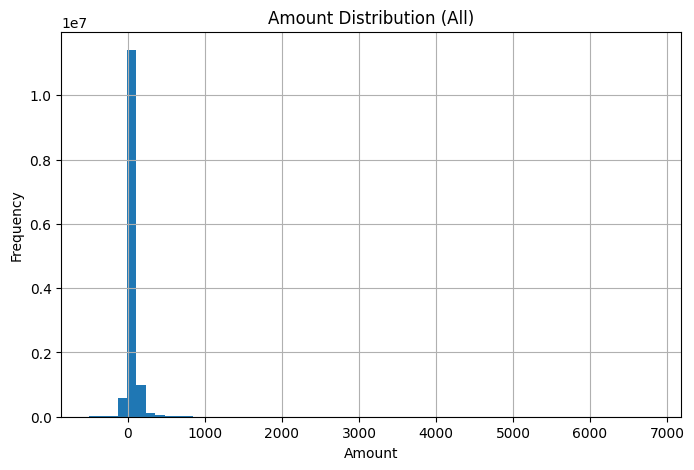

<Figure size 800x500 with 0 Axes>

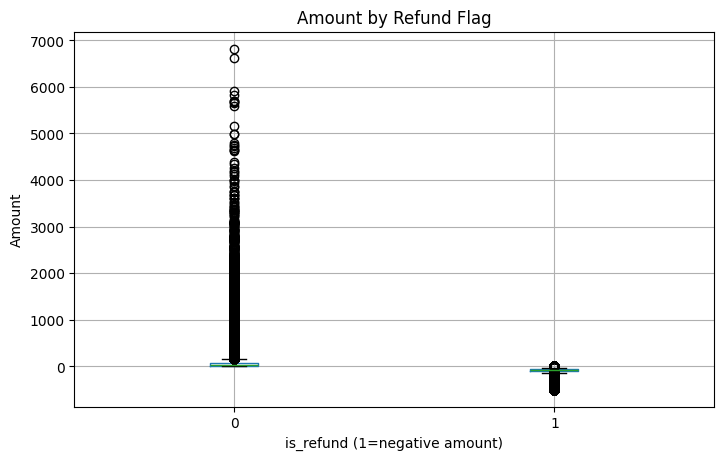

Top use_chip values:


use_chip
Swipe Transaction     6967185
Chip Transaction      4780818
Online Transaction    1557912
Name: count, dtype: int64

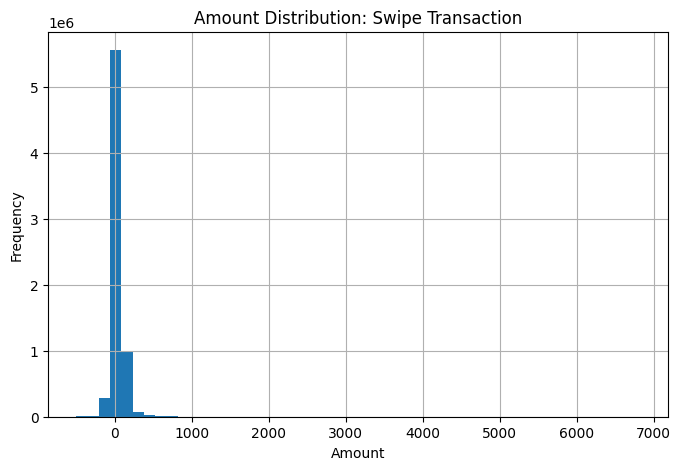

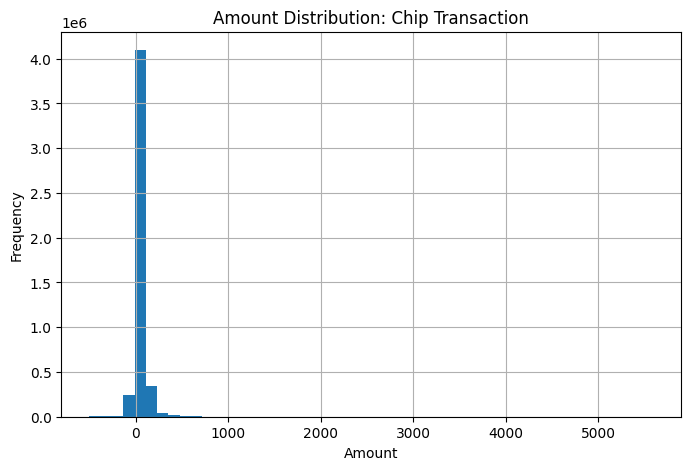

,count,mean,median
hour,,,
0,140582,49.351715,34.560
1,115586,57.336974,35.650
2,112787,49.347765,28.800
3,103478,54.823768,36.620
4,114985,55.374053,40.650
5,182965,45.712078,27.690
6,758856,33.984444,17.140
7,901756,32.939868,20.500
8,880501,35.124243,18.770


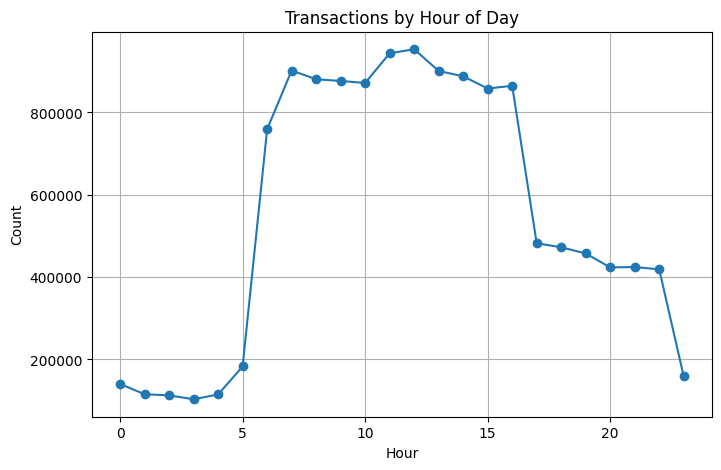

,med_amount,n
merchant_id,,
59935,30.97,610053
27092,80.00,589140
61195,18.64,562410
39021,34.47,440281
43293,34.39,362842
22204,18.34,347511
14528,1.29,333505
60569,51.87,301657
50783,11.54,298231


In [3]:

print("Rows:", len(df))
print("Time coverage:", df['ts'].min(), "→", df['ts'].max())
display(df[['amount','amount_num','is_refund','use_chip','merchant_state','mcc','errors']].describe(include='all').transpose().head(20))

# Amount histograms
plt.figure()
df['amount_num'].dropna().hist(bins=60)
plt.title('Amount Distribution (All)')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# Refund vs non-refund
plt.figure()
df.boxplot(column='amount_num', by='is_refund')
plt.title('Amount by Refund Flag')
plt.suptitle('')
plt.xlabel('is_refund (1=negative amount)')
plt.ylabel('Amount')
plt.show()

# use_chip breakdown
if 'use_chip' in df.columns:
    vc = df['use_chip'].value_counts(dropna=False).head(10)
    print("Top use_chip values:")
    display(vc)
    # Amount by top two device types (if available)
    top_types = vc.index.tolist()[:2]
    for t in top_types:
        sub = df[df['use_chip']==t]['amount_num'].dropna()
        if len(sub)>0:
            plt.figure()
            sub.hist(bins=50)
            plt.title(f'Amount Distribution: {t}')
            plt.xlabel('Amount')
            plt.ylabel('Frequency')
            plt.show()

# Time-of-day pattern
if df['ts'].notna().any():
    hourly = df.groupby('hour')['amount_num'].agg(['count','mean','median'])
    display(hourly)
    plt.figure()
    hourly['count'].plot(kind='line', marker='o')
    plt.title('Transactions by Hour of Day')
    plt.xlabel('Hour')
    plt.ylabel('Count')
    plt.show()

# Merchant risk proxy: per-merchant median amount & volume
if 'merchant_id' in df.columns:
    g = df.groupby('merchant_id')['amount_num'].agg(['median','count']).rename(columns={'median':'med_amount','count':'n'})
    display(g.sort_values('n', ascending=False).head(10))


NEXT_PART
## Hypotheses

**H₀ (Null):** The **distribution of transaction amounts** (log1p) is the **same across `use_chip` categories**.  
**Hₐ (Alt):** At least one `use_chip` category has a **different** amount distribution.

> Motivation: Channel/entry‑mode often correlates with risk; if fraudsters prefer less‑secured modes, the amount distribution may differ.

**H₀₂:** Transactions with an entry in `errors` are **no more anomalous** (by an unsupervised anomaly score) than those without.  
**Hₐ₂:** Transactions with an `errors` value look **more anomalous**.


### Test 1 — Amount vs. `use_chip`

In [4]:

# Prepare data
df['log_amount'] = np.log1p(df['amount_num'].clip(lower=0))

groups = df[['use_chip','log_amount']].dropna()
group_sizes = groups['use_chip'].value_counts()
display(group_sizes.head())

decision1 = "Not evaluated"

if stats is not None and groups.shape[0] > 0:
    # Use Kruskal–Wallis across all groups with n>=30
    valid_groups = [g['log_amount'].values for _, g in groups.groupby('use_chip') if len(g) >= 30]
    if len(valid_groups) >= 2:
        H, p = stats.kruskal(*valid_groups)
        print(f"Kruskal–Wallis across use_chip groups: H={H:.3f}, p={p:.3e}")
        alpha = 0.05
        decision1 = "Reject H₀ — distributions differ across use_chip." if p < alpha else "Fail to reject H₀ — no strong evidence of difference."
    else:
        decision1 = "Insufficient group sizes (need ≥30 per group) for Kruskal–Wallis."
else:
    decision1 = "SciPy not available; skip statistical test."

print("Decision (Test 1):", decision1)


use_chip
Swipe Transaction     6967185
Chip Transaction      4780818
Online Transaction    1557912
Name: count, dtype: int64

Kruskal–Wallis across use_chip groups: H=129968.979, p=0.000e+00
Decision (Test 1): Reject H₀ — distributions differ across use_chip.


### Test 2 — Are `errors` rows more anomalous? (Unsupervised)

Mann–Whitney U on anomaly scores: U=1248452469346.0, p=0.000e+00
Decision (Test 2): Reject H₀₂ — `errors` rows look more/less anomalous.


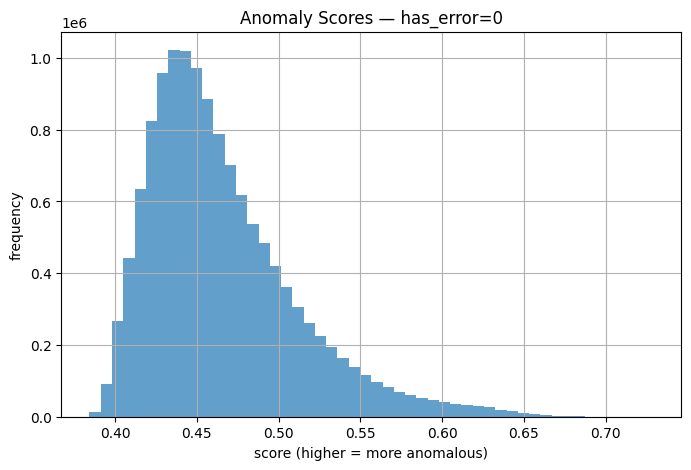

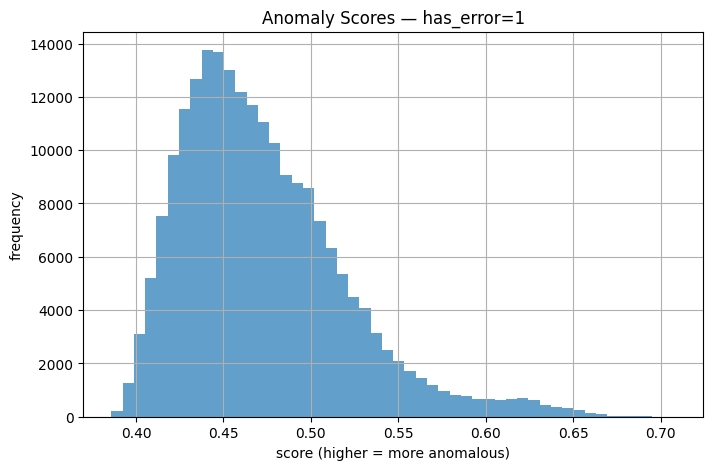

In [ ]:

decision2 = "Not evaluated"

if SKLEARN_AVAILABLE:
    work = df[['amount_num','hour','dow','merchant_id','card_id','client_id','mcc','errors']].copy()
    work['has_error'] = (~work['errors'].isna()).astype(int)
    work = work.drop(columns=['errors'])

    # Per-card z-score of amount as a feature
    z = work[['card_id','amount_num']].copy()
    z['card_mean'] = z.groupby('card_id')['amount_num'].transform('mean')
    z['card_std'] = z.groupby('card_id')['amount_num'].transform('std')
    work['amount_z_by_card'] = (z['amount_num'] - z['card_mean']) / z['card_std']

    # Frequency encodings for merchant/card (risk proxy)
    for c in ['merchant_id','card_id','client_id','mcc']:
        freq = work[c].value_counts()
        work[c+'_freq'] = work[c].map(freq)

    feats = ['amount_num','hour','dow','amount_z_by_card','merchant_id_freq','card_id_freq','client_id_freq','mcc_freq']
    X = work[feats].fillna(0).astype(float).values

    # Scale and fit IsolationForest
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    iso = IsolationForest(n_estimators=200, contamination='auto', random_state=42)
    iso.fit(Xs)
    scores = -iso.score_samples(Xs)  # higher = more anomalous

    work['anom_score'] = scores

    # Compare anomaly score for has_error groups
    g0 = work[work['has_error']==0]['anom_score']
    g1 = work[work['has_error']==1]['anom_score']

    if stats is not None and len(g0)>10 and len(g1)>10:
        # Mann–Whitney U (robust, nonparametric)
        U, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
        print(f"Mann–Whitney U on anomaly scores: U={U:.1f}, p={p:.3e}")
        alpha = 0.05
        decision2 = "Reject H₀₂ — `errors` rows look more/less anomalous." if p < alpha else "Fail to reject H₀₂ — no strong evidence that `errors` rows differ."
    else:
        decision2 = "Insufficient data or SciPy unavailable to test."
    print("Decision (Test 2):", decision2)

    # Simple visualization
    plt.figure()
    g0.hist(bins=50, alpha=0.7)
    plt.title('Anomaly Scores — has_error=0')
    plt.xlabel('score (higher = more anomalous)')
    plt.ylabel('frequency')
    plt.show()

    plt.figure()
    g1.hist(bins=50, alpha=0.7)
    plt.title('Anomaly Scores — has_error=1')
    plt.xlabel('score (higher = more anomalous)')
    plt.ylabel('frequency')
    plt.show()
else:
    print("scikit-learn not available; skipping unsupervised test.")
#NEXT_PART


## Conclusion

These conclusions are **EDA-level** and depend on this file’s contents at hand.  
For production fraud detection you would (1) obtain labels (even partial/weak), (2) add velocity, device, and geo features, and (3) combine **rules + ML** with cost‑aware thresholds.
